In [2]:
# 라이브러리 임포트
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas_datareader import data as pdr
import statsmodels.api as sm

plt.style.use('seaborn-v0_8')
%matplotlib inline

print("라이브러리 로드 완료!")

라이브러리 로드 완료!


In [3]:
# 포트폴리오 데이터 로드
tickers_us = ['JEPI', 'SCHD', 'PDBC', 'TSLA', 'CRCL']
prices_us = yf.download(tickers_us, start='2025-06-05', end='2026-04-12')['Close']

usdkrw = yf.download('KRW=X', start='2025-06-05', end='2026-04-12')['Close'].squeeze()
kodex_prices = yf.download('476800.KS', start='2025-06-05', end='2026-04-12')['Close'].squeeze()
kodex_prices.index = kodex_prices.index.tz_localize(None)
kodex_usd = kodex_prices / usdkrw

prices_full = prices_us.copy()
prices_full['KODEX'] = kodex_usd
prices_full = prices_full.dropna()

portfolio_full = {
    'JEPI': 120.25, 'SCHD': 233.46, 'PDBC': 391.58,
    'TSLA': 18.22, 'CRCL': 55.25, 'KODEX': 1600,
}

tickers_full = list(portfolio_full.keys())
shares_full = pd.Series(portfolio_full)
latest_prices = prices_full.iloc[-1]
market_value = shares_full * latest_prices
total_value = float(market_value.sum())
weights_full = market_value / total_value
returns_full = prices_full.pct_change().dropna()
portfolio_returns = (returns_full * weights_full).sum(axis=1)

# Fama-French 3팩터 데이터 다운로드
ff3 = pdr.get_data_famafrench('F-F_Research_Data_Factors_daily', start='2025-06-05')[0]
ff3.index = pd.to_datetime(ff3.index, format='%Y%m%d')
ff3 = ff3 / 100  # 퍼센트 → 소수점 변환

print("데이터 로드 완료!")
print(ff3.tail())

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
C:\Users\chanc\AppData\Local\Temp\ipykernel_27716\1739637856.py:29: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff3 = pdr.get_data_famafrench('F-F_Research_Data_Factors_daily', start='2025-06-05')[0]


데이터 로드 완료!
            Mkt-RF     SMB     HML      RF
Date                                      
2026-02-23 -0.0118 -0.0030 -0.0131  0.0001
2026-02-24  0.0083  0.0051 -0.0066  0.0001
2026-02-25  0.0079 -0.0037  0.0049  0.0001
2026-02-26 -0.0047  0.0063  0.0032  0.0001
2026-02-27 -0.0051 -0.0044 -0.0125  0.0001


In [4]:
# 데이터 합치기
portfolio_df = pd.DataFrame({'portfolio': portfolio_returns})
ff3_aligned = ff3.reindex(portfolio_df.index).dropna()
portfolio_aligned = portfolio_df.reindex(ff3_aligned.index).dropna()

# 초과수익률 계산 (포트폴리오 수익률 - 무위험수익률)
excess_returns = portfolio_aligned['portfolio'] - ff3_aligned['RF']

# Fama-French 3팩터 회귀분석
X = ff3_aligned[['Mkt-RF', 'SMB', 'HML']]
X = sm.add_constant(X)
y = excess_returns

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.264
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     20.21
Date:                Sun, 12 Apr 2026   Prob (F-statistic):           3.05e-11
Time:                        01:04:37   Log-Likelihood:                 524.15
No. Observations:                 173   AIC:                            -1040.
Df Residuals:                     169   BIC:                            -1028.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.001      0.633      0.5

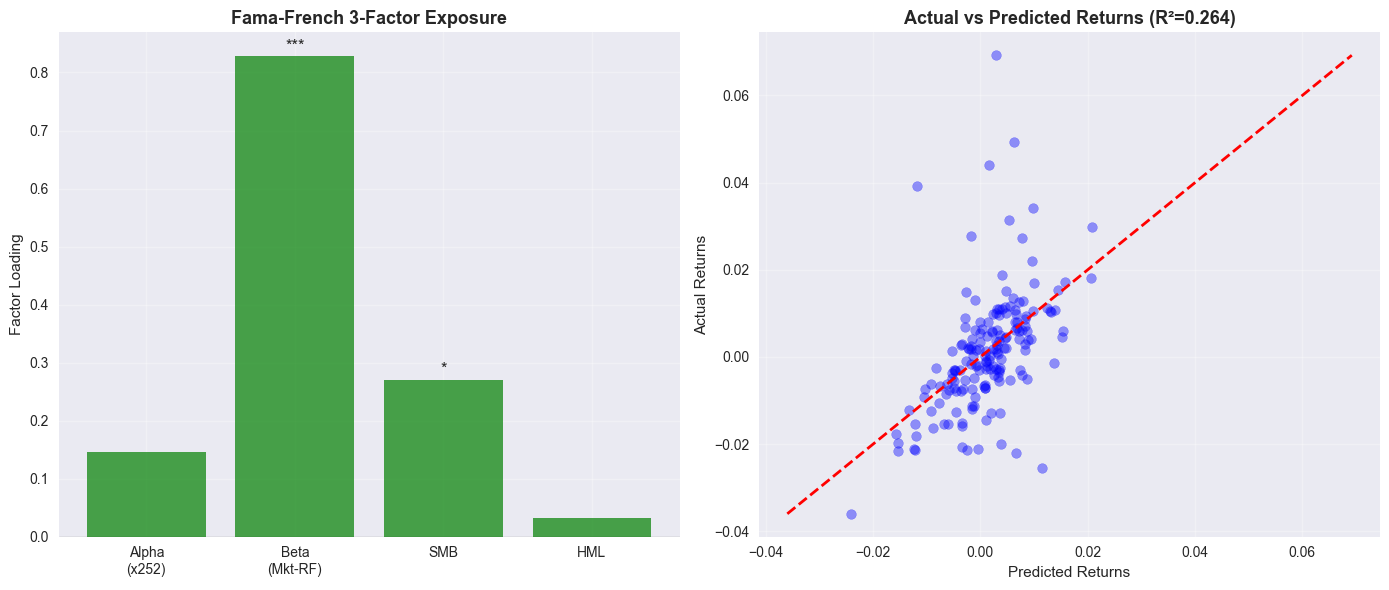


=== 팩터 분석 요약 ===
Alpha (연환산): 14.59%
Market Beta: 0.828
SMB (Size): 0.270
HML (Value): 0.032
R-squared: 0.264


In [5]:
# 팩터 노출도 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 팩터 계수 바차트
factors = ['Alpha\n(x252)', 'Beta\n(Mkt-RF)', 'SMB', 'HML']
coefs = [model.params['const']*252, 
         model.params['Mkt-RF'],
         model.params['SMB'], 
         model.params['HML']]
pvalues = [model.pvalues['const'],
           model.pvalues['Mkt-RF'],
           model.pvalues['SMB'],
           model.pvalues['HML']]

colors = ['green' if c > 0 else 'red' for c in coefs]
bars = axes[0].bar(factors, coefs, color=colors, alpha=0.7)

# 유의성 표시
for bar, pval in zip(bars, pvalues):
    significance = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
    axes[0].text(bar.get_x() + bar.get_width()/2, 
                bar.get_height() + 0.01,
                significance, ha='center', fontsize=12)

axes[0].axhline(y=0, color='black', linewidth=0.8)
axes[0].set_title('Fama-French 3-Factor Exposure', 
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Factor Loading')
axes[0].grid(True, alpha=0.3)

# 실제 vs 예측 수익률
predicted = model.fittedvalues
axes[1].scatter(predicted, excess_returns, alpha=0.4, color='blue')
axes[1].plot([excess_returns.min(), excess_returns.max()],
             [excess_returns.min(), excess_returns.max()],
             color='red', linestyle='--', linewidth=2)
axes[1].set_title(f'Actual vs Predicted Returns (R²={model.rsquared:.3f})',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Returns')
axes[1].set_ylabel('Actual Returns')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n=== 팩터 분석 요약 ===")
print(f"Alpha (연환산): {model.params['const']*252*100:.2f}%")
print(f"Market Beta: {model.params['Mkt-RF']:.3f}")
print(f"SMB (Size): {model.params['SMB']:.3f}")
print(f"HML (Value): {model.params['HML']:.3f}")
print(f"R-squared: {model.rsquared:.3f}")